*Aprendizaje Profundo*  
*Tarea -* Proyecto Regresion Logistica Clasficador de Habitos  
*Autores:* Cervantes Jazmin, González Daniel  
*Profesor:* Dr. Sebastian Salazar

# Clasificador de Habitos Saludables

## Cargar Librerias

In [1]:
import os
import numpy as np
import pandas as pd
import tkinter as tk
import matplotlib.pyplot as plt
from datetime import date, datetime, timedelta
from dateutil.relativedelta import relativedelta
from tkinter import messagebox

## Generar Datos

In [2]:
rng = np.random.default_rng(10)
n = 364  # total de registros

# Días saludables (1)
sueño_ok = rng.normal(7.5, 0.6, n//2)
agua_ok = rng.normal(2.4, 0.4, n//2)
pasos_ok = rng.normal(9500, 1500, n//2)
comida_chatarra_ok = rng.normal(300, 150, n//2)
estres_ok = rng.normal(3.5, 1.5, n//2)
saludable = np.ones(n//2, dtype=int)

# Días no saludables (0)
sueño_bad = rng.normal(5.6, 0.8, n//2)
agua_bad = rng.normal(1.3, 0.3, n//2)
pasos_bad = rng.normal(3500, 1000, n//2)
comida_chatarra_bad = rng.normal(800, 200, n//2)
estres_bad = rng.normal(7.0, 1.5, n//2)
saludable_bad = np.zeros(n//2, dtype=int)

# Unir ambos conjuntos
X = np.concatenate([
    np.column_stack([sueño_ok, agua_ok, pasos_ok, comida_chatarra_ok, estres_ok, saludable]),
    np.column_stack([sueño_bad, agua_bad, pasos_bad, comida_chatarra_bad, estres_bad, saludable_bad])
])

Estres
| Valor    | Significado                                              |
| -------- | -------------------------------------------------------- |
| 1–2  | Día muy tranquilo, relajado.                             |
| 3–4  | Algo de tensión, pero manejable.                         |
| 5–6  | Estrés moderado (día normal de trabajo o estudio).       |
| 7–8  | Día pesado o agitado.                                    |
| 9–10 | Estrés alto: ansiedad, exceso de tareas, preocupaciones. |


In [3]:
df = pd.DataFrame(X, columns=["sueño(hr)", "agua(lt)", "pasos", "comida_chatarra(kcal)", "estres", "saludable"])
df = df.round({'sueño(hr)': 2,'agua(lt)': 2,'pasos': 0,'comida_chatarra(kcal)': 2,'estres': 0})


In [8]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
fechas = pd.date_range(end=pd.Timestamp.today(), periods=len(df), freq='D')
df['Fecha'] = fechas.strftime('%Y-%m-%d')

df.head()
#df.to_csv("habitos.csv", index=False, float_format="%.2f")

,sueño(hr),agua(lt),pasos,comida_chatarra(kcal),estres,saludable,Fecha
0,4.97,0.86,4212.0,642.64,7.0,0.0,2024-10-31
1,8.14,2.55,10841.0,305.27,3.0,1.0,2024-11-01
2,5.57,1.65,3276.0,483.54,8.0,0.0,2024-11-02
3,7.42,2.29,9787.0,101.65,2.0,1.0,2024-11-03
4,5.84,0.96,4685.0,648.74,8.0,0.0,2024-11-04


In [9]:
X = df[['sueño(hr)','agua(lt)','pasos','comida_chatarra(kcal)','estres']].to_numpy(dtype=float)
y = df['saludable'].to_numpy(dtype=int)

## Normalizacion (z-score)

In [10]:
X_mean = X.mean(axis=0, keepdims=True)
X_std  = X.std(axis=0, keepdims=True) + 1e-8
Xz = (X - X_mean) / X_std
Xz

array([[-1.32415412, -1.49854327, -0.71061733,  0.32599866,  0.80116707],
       [ 1.48404848,  1.10884996,  1.31995496, -0.77414822, -0.95825865],
       [-0.79263312, -0.27970264, -0.9973296 , -0.19281857,  1.2410235 ],
       ...,
       [ 0.66904962,  0.50714383,  0.53547833,  0.1680056 , -0.95825865],
       [ 1.24486403,  1.72598445,  0.73917882, -1.54595   , -0.51840222],
       [ 0.52731069,  2.06540842,  0.41111381, -1.35430393, -0.07854579]],
      shape=(364, 5))

## Separar en entrenamiento y test

In [11]:
idx = np.arange(len(Xz))
rng.shuffle(idx)
split = int(0.8 * len(idx))
tr, te = idx[:split], idx[split:]
Xtr, ytr = Xz[tr], y[tr]
Xte, yte = Xz[te], y[te]
Xtr.shape, Xte.shape


((291, 5), (73, 5))

# Regresion Logistica

In [12]:
def sigmoid(z):
    z = np.clip(z, -40, 40)
    return 1.0 / (1.0 + np.exp(-z))

def forward(X, W, b):
    return sigmoid(X @ W + b)

def loss_logistic(y_true, y_prob, eps=1e-9):
    y_prob = np.clip(y_prob, eps, 1-eps)
    return -np.mean(y_true*np.log(y_prob) + (1-y_true)*np.log(1-y_prob))

def accuracy(y_true, y_pred_bin):
    return np.mean(y_true == y_pred_bin)

## Entrenamiento

In [13]:
d = Xtr.shape[1]
W = np.zeros(d)      # pesos
b = 0.0              # sesgo
lr = 0.1
epochs = 1500

hist = []
for ep in range(1, epochs+1):
    yprob = forward(Xtr, W, b)
    diff = (yprob - ytr)
    gW = (Xtr.T @ diff) / len(Xtr)
    gb = np.mean(diff)
    # Actualización
    W -= lr * gW
    b -= lr * gb
    if ep % 100 == 0 or ep == 1:
        ltr = loss_logistic(ytr, yprob)
        hist.append((ep, ltr))
        print(f"[ep {ep:4d}] loss={ltr:.4f}")


[ep    1] loss=0.6931
[ep  100] loss=0.0474
[ep  200] loss=0.0275
[ep  300] loss=0.0202
[ep  400] loss=0.0163
[ep  500] loss=0.0138
[ep  600] loss=0.0121
[ep  700] loss=0.0109
[ep  800] loss=0.0099
[ep  900] loss=0.0091
[ep 1000] loss=0.0084
[ep 1100] loss=0.0079
[ep 1200] loss=0.0074
[ep 1300] loss=0.0070
[ep 1400] loss=0.0067
[ep 1500] loss=0.0064


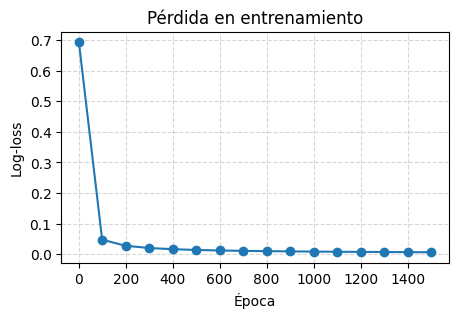

In [14]:
plt.figure(figsize=(5,3))
xs = [e for e,_ in hist]
ys = [l for _,l in hist]
plt.plot(xs, ys, marker='o')
plt.title("Pérdida en entrenamiento")
plt.xlabel("Época")
plt.ylabel("Log-loss")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Metricas

In [15]:
# Predicciones
yprob_te = forward(Xte, W, b)

# Umbral 0.5 por defecto
yth_te = (yprob_te >= 0.5).astype(int)

# Métricas manuales
acc = accuracy(yte, yth_te)

TP = int(np.sum((yte==1) & (yth_te==1)))
TN = int(np.sum((yte==0) & (yth_te==0)))
FP = int(np.sum((yte==0) & (yth_te==1)))
FN = int(np.sum((yte==1) & (yth_te==0)))

precision = TP / (TP + FP + 1e-9)
recall    = TP / (TP + FN + 1e-9)
f1        = 2*precision*recall / (precision + recall + 1e-9)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1       : {f1:.3f}")
print("Matriz de confusión [ [TN FP] [FN TP] ] =")
print(np.array([[TN, FP],[FN, TP]]))


Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1       : 1.000
Matriz de confusión [ [TN FP] [FN TP] ] =
[[37  0]
 [ 0 36]]


# Ejemplo

In [16]:
# 7h de sueño, 2.1L agua, 9000 pasos, 300 cal chatarra, estrés=4
nuevo = np.array([[7.0, 2.1, 9000, 300, 4.0]], dtype=float)
nuevo_z = (nuevo - X_mean) / X_std
p_salud = forward(nuevo_z, W, b)[0]
print(f"Probabilidad de 'día saludable': {p_salud:.3f}")
print("Clase predicha:", int(p_salud >= 0.5))


Probabilidad de 'día saludable': 0.993
Clase predicha: 1


# Interfaz

## Funciones

In [123]:
CSV_PATH = "habitos.csv"
CSV_COLUMNS = [ "sueño(hr)", "agua(lt)", "pasos", "comida_chatarra(kcal)", "estres","saludable", "Fecha"]

In [124]:
def _to_float(s: str):
    """Convierte string a float tolerando espacios y coma decimal."""
    s = s.strip()
    if not s:
        return None
    s = s.replace(',', '.')  # permitir 3,5
    try:
        return float(s)
    except ValueError:
        return None

def _read_csv_loose(path=CSV_PATH):
    """
    Lee el CSV con el motor 'python' y salta filas irrecuperables.
    Devuelve un DF con al menos las columnas de FILE_COLUMNS (faltantes -> NaN).
    """
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return pd.DataFrame(columns=CSV_COLUMNS)

    try:
        df = pd.read_csv(path)  # intento simple
    except Exception:
        df = pd.read_csv(path, engine="python", on_bad_lines="skip")

    # Asegurar columnas (sin reescribir el disco)
    for c in CSV_COLUMNS:
        if c not in df.columns:
            df[c] = np.nan
    df = df[CSV_COLUMNS]

    # Tipos
    df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
    # Numéricos con tolerancia
    for c in ["sueño(hr)", "agua(lt)", "pasos", "comida_chatarra(kcal)", "estres"]:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    df["saludable"] = pd.to_numeric(df["saludable"], errors="coerce").round().fillna(0).astype(int)
    return df


def _compute_promedios(path=CSV_PATH):
    """
    Devuelve:
      prom_5d (0..1), status_5d ('SALUDABLE'/'NO saludable'),
      prom_3m (0..1), status_3m ('SALUDABLE'/'NO saludable')
    Usa 'Fecha' y 'saludable' del archivo original.
    """
    df = _read_csv_loose(path)
    df = df.dropna(subset=["Fecha"])
    if df.empty:
        return 0.0, "NO saludable", 0.0, "NO saludable"

    hoy = date.today()

    # Últimos 5 días calendario (incluye hoy)
    ini_5d = hoy - timedelta(days=4)
    m5 = (df["Fecha"].dt.date >= ini_5d) & (df["Fecha"].dt.date <= hoy)
    prom_5d = float(df.loc[m5, "saludable"].astype(float).mean()) if m5.any() else 0.0
    status_5d = "SALUDABLE" if prom_5d >= 0.60 else "NO saludable"

    # Últimos 3 meses naturales
    ini_3m = hoy - relativedelta(months=3)
    m3 = (df["Fecha"] >= pd.Timestamp(ini_3m)) & (df["Fecha"] <= pd.Timestamp(hoy))
    prom_3m = float(df.loc[m3, "saludable"].astype(float).mean()) if m3.any() else 0.0
    status_3m = "SALUDABLE" if prom_3m >= 0.60 else "NO saludable"

    # Evitar NaN
    if np.isnan(prom_5d): 
        prom_5d, status_5d = 0.0, "NO saludable"
    if np.isnan(prom_3m): 
        prom_3m, status_3m = 0.0, "NO saludable"

    return prom_5d, status_5d, prom_3m, status_3m


def _append_row(row: dict, path=CSV_PATH):
    """
    Agrega UNA fila con las 7 columnas EXACTAS del archivo.
    Si no existe, crea el archivo con ese encabezado.
    """
    exists = os.path.exists(path)
    # Armar fila en el orden exacto
    full_row = {c: np.nan for c in CSV_COLUMNS}
    full_row.update(row)  # sobreescribe con valores presentes
    df_row = pd.DataFrame([full_row], columns=CSV_COLUMNS)
    df_row.to_csv(path, mode="a", index=False, header=not exists)

In [125]:
def add_day():
    # 1) Leer entradas
    vals = {
        "sueño(hr)": _to_float(txt_sueño.get()),
        "agua(lt)": _to_float(txt_agua.get()),
        "pasos": _to_float(txt_pasos.get()),
        "comida_chatarra(kcal)": _to_float(txt_chatarra.get()),
        "estres": _to_float(txt_estres.get()),
    }
    faltantes = [k for k,v in vals.items() if v is None]
    if faltantes:
        messagebox.showerror(
            "Datos inválidos",
            "Revisa: " + ", ".join(faltantes) + ". Usa números (coma o punto)."
        )
        return

    # 2) Preparar vector para tu modelo (usando el orden esperado por tu X_mean/X_std)
    #    Mapea a tu orden interno: [sueño_hr, agua_lt, pasos, chatarra_kcal, estres]
    nuevo = np.array([[
        vals["sueño(hr)"],
        vals["agua(lt)"],
        vals["pasos"],
        vals["comida_chatarra(kcal)"],
        vals["estres"]
    ]], dtype=float)

    safe_std = np.where(X_std == 0, 1.0, X_std)
    nuevo_z  = (nuevo - X_mean) / safe_std

    # 3) Predicción
    p_salud = float(forward(nuevo_z, W, b)[0])      # probabilidad
    saludable = int(p_salud >= 0.5)                 # clase 0/1

    # 4) Guardar SOLO en 7 columnas (no escribimos la probabilidad para no romper el CSV)
    row = {
        "sueño(hr)": vals["sueño(hr)"],
        "agua(lt)": vals["agua(lt)"],
        "pasos": vals["pasos"],
        "comida_chatarra(kcal)": vals["comida_chatarra(kcal)"],
        "estres": vals["estres"],
        "saludable": saludable,
        "Fecha": date.today().isoformat(),
    }
    _append_row(row, CSV_PATH)

        # 5) Promedios y estatus (lector tolerante)
    prom_5d, status_5d, prom_3m, status_3m = _compute_promedios(CSV_PATH)

    # 6) Actualizar GUI (muestra prob. y promedios + estatus)
    txt_pred = "SALUDABLE" if saludable else "NO saludable"
    label_resultado.config(
        text=(
            f"Predicción: \n Hoy: {txt_pred} ({p_salud*100:.1f}%)  \n"
            f"5 días: {prom_5d*100:.1f}% → {status_5d}  \n"
            f"3 meses: {prom_3m*100:.1f}% → {status_3m}"
        )
    )


## Ventana

In [126]:
CANVAS_SIZE = 300

root = tk.Tk()
root.title("Clasificador de Hábitos Saludables")

''

## Datos de entrada

In [127]:
label_sueño = tk.Label(root, text="Sueño (hr):")
label_sueño.grid(row=1, column=1, padx=10, pady=5)
txt_sueño = tk.Entry(root)
txt_sueño.grid(row=1, column=2, padx=10, pady=5)

label_agua = tk.Label(root, text="Agua (lt):")
label_agua.grid(row=2, column=1, padx=10, pady=5)
txt_agua = tk.Entry(root)
txt_agua.grid(row=2, column=2, padx=10, pady=5)

label_pasos = tk.Label(root, text="Pasos:")
label_pasos.grid(row=3, column=1, padx=10, pady=5)
txt_pasos = tk.Entry(root)
txt_pasos.grid(row=3, column=2, padx=10, pady=5)

label_chatarra = tk.Label(root, text="Comida chatarra (kcal):")
label_chatarra.grid(row=4, column=1, padx=10, pady=5)
txt_chatarra = tk.Entry(root)
txt_chatarra.grid(row=4, column=2, padx=10, pady=5)

label_estres = tk.Label(root, text="Estrés(1-10):")
label_estres.grid(row=5, column=1, padx=10, pady=5)
txt_estres = tk.Entry(root)
txt_estres.grid(row=5, column=2, padx=10, pady=5)

label_prediccion = tk.Label(root, text="Tu día fue:")
label_prediccion.grid(row=2, column=3, padx=10, pady=5)
label_resultado = tk.Label(root, text="(esperando datos...)")
label_resultado.grid(row=3, column=3, padx=10, pady=5)

## Botones

In [128]:
btn_add = tk.Button(root, text="Agregar Día", command=add_day)
btn_add.grid(row=1, column=3, padx=10, pady=5)

## GUI

In [129]:
root.mainloop()